# A3: Self-Supervised Learning

In this lab we explore **Self-Supervised Learning (SSL)** — learning visual representations **without any human labels**.

SSL derives a supervision signal from the data itself, enabling the **pre-train → fine-tune** paradigm that powers modern deep learning.

---

## SSL Timeline

| Model | Year | Key Idea | Limitation |
|---|---|---|---|
| **SimCLR** | 2020 | Contrastive: pull same-image crops together | Needs huge batch (4096+) |
| **MoCo v2** | 2020 | Memory bank of negatives | More complex training |
| **BYOL** | 2020 | No negatives — EMA teacher + predictor MLP | Asymmetric architecture needed |
| **DINO** | 2021 | Self-distillation on ViT + centering trick | Requires careful tuning |
| **MAE** | 2022 | Reconstruct 75%-masked patches | Needs longer training |

**This lab implements all three major families:** contrastive (SimCLR), self-distillation (DINO), and reconstruction (MAE).

---

## Evaluation: Linear Probing

The standard SSL benchmark: freeze the encoder, train only a single linear layer on top with labels. High accuracy → the encoder learned linearly separable, semantically meaningful features without ever seeing a label.

```
Pretrained Encoder (frozen) → h → Linear classifier → class label
                                       ↑ only this is trained with labels
```


In [1]:
!pip install torch torchvision timm scikit-learn tqdm matplotlib numpy pillow -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.manifold import TSNE
import random, os, math, time

# Set environment variables to prevent duplicate OpenMP library initialization crashes on macOS
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Cross-platform device detection: CUDA (NVIDIA), MPS (Apple Silicon), CPU (fallback)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Dynamic DataLoader multiprocessing configuration for notebook stability
# num_workers > 0 on macOS Jupyter can trigger child process spawn loops and kernel crashes
NUM_WORKERS = 0 if device.type == 'mps' else 2
print(f'Using NUM_WORKERS: {NUM_WORKERS}')

def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
os.makedirs('saved', exist_ok=True)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

EVAL_TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
])


Using device: cuda
Using NUM_WORKERS: 2


In [3]:

# --- Results Logging Utility ---
import json
import os

def log_result(config_name, metrics):
    os.makedirs('saved', exist_ok=True)
    filepath = 'saved/results.json'
    if os.path.exists(filepath):
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except Exception:
            data = {}
    else:
        data = {}
    
    if config_name not in data:
        data[config_name] = {}
        
    for k, v in metrics.items():
        data[config_name][k] = v
        
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2)
    print(f"Logged results for '{config_name}' in {filepath}")


---
## Part 1: SimCLR — Contrastive Learning

SimCLR (Chen et al., 2020): two augmented views of the same image should be close in feature space; views from different images should be far apart.

```
Image x ──[aug]──▶ x_i ──[Encoder f]──▶ h_i ──[Projector g]──▶ z_i ──┐
        └──[aug]──▶ x_j ──[Encoder f]──▶ h_j ──[Projector g]──▶ z_j ──┴──▶ NT-Xent Loss
```

**Projector head:** loss is on `z`, downstream uses `h`. The projector absorbs augmentation-specific information — removing it at eval time gives *better* features.

**NT-Xent Loss:** for batch size N, treat other 2N-2 views as negatives. Temperature τ controls sharpness.


<img src="figures/simclr_arch.png" width="750"/>


In [4]:
class SimCLRAugmentation:
    """Returns two independently augmented views of the same image."""
    def __init__(self, image_size=32):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=3),
            transforms.ToTensor(),
            transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)


class CIFAR10SSL(Dataset):
    def __init__(self, root='./data', train=True):
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.augment = SimCLRAugmentation()
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        x_i, x_j = self.augment(img)
        return x_i, x_j, label


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    def forward(self, z_i, z_j):
        N = z_i.shape[0]
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)
        z = torch.cat([z_i, z_j], dim=0)
        sim = torch.mm(z, z.T) / self.temperature
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim = sim.masked_fill(mask, float('-inf'))
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
        return F.cross_entropy(sim, labels)


class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128)
        )
    def forward(self, x_i, x_j):
        h_i = torch.flatten(self.encoder(x_i), 1)
        h_j = torch.flatten(self.encoder(x_j), 1)
        return self.projector(h_i), self.projector(h_j), h_i, h_j

In [5]:
import time

# --- Train SimCLR ---
BATCH_SIZE, EPOCHS = 256, 10
train_loader = DataLoader(CIFAR10SSL(), batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, drop_last=True)
simclr    = SimCLR().to(device)
criterion = NTXentLoss(temperature=0.5)
optimizer = torch.optim.Adam(simclr.parameters(), lr=3e-4, weight_decay=1e-4)

simclr_losses = []
epoch_times = []
total_start = time.time()

for epoch in range(EPOCHS):
    simclr.train()
    ep = []
    t0 = time.time()
    for x_i, x_j, _ in tqdm(train_loader, desc=f'SimCLR {epoch+1}/{EPOCHS}'):
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i, z_j, _, _ = simclr(x_i, x_j)
        loss = criterion(z_i, z_j)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep.append(loss.item())
    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    simclr_losses.append(np.mean(ep))
    print(f'Epoch {epoch+1:02d} | Loss: {np.mean(ep):.4f} | Time: {elapsed:.1f}s')

total_time = time.time() - total_start
print(f'\nTotal: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(epoch_times):.1f}s')
torch.save(simclr.state_dict(), 'saved/simclr.pt')

# Log SimCLR Train Metrics
log_result('simclr', {
    'train_loss': simclr_losses,
    'epoch_times': epoch_times,
    'total_time_min': total_time / 60
})


/home/jupyter-st126010/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
SimCLR 1/10: 100%|██████████| 195/195 [01:17<00:00,  2.52it/s]


Epoch 01 | Loss: 5.4218 | Time: 77.4s


SimCLR 2/10: 100%|██████████| 195/195 [01:13<00:00,  2.65it/s]


Epoch 02 | Loss: 5.2158 | Time: 73.7s


SimCLR 3/10: 100%|██████████| 195/195 [01:16<00:00,  2.55it/s]


...

Epoch 08 | Loss: 4.9746 | Time: 75.3s


SimCLR 9/10: 100%|██████████| 195/195 [01:26<00:00,  2.26it/s]


Epoch 09 | Loss: 4.9589 | Time: 86.2s


SimCLR 10/10: 100%|██████████| 195/195 [01:17<00:00,  2.52it/s]

Epoch 10 | Loss: 4.9437 | Time: 77.3s

Total: 12.8 min  |  Avg/epoch: 77.0s
Logged results for 'simclr' in saved/results.json


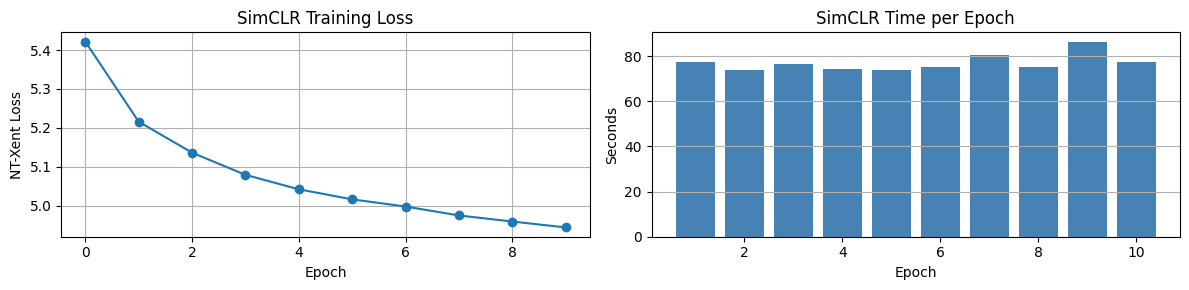

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(simclr_losses, marker='o')
ax1.set_title('SimCLR Training Loss'); 
ax1.set_xlabel('Epoch'); 
ax1.set_ylabel('NT-Xent Loss'); 
ax1.grid(True)
ax2.bar(range(1, len(epoch_times)+1), epoch_times, color='steelblue')
ax2.set_title('SimCLR Time per Epoch'); 
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Seconds'); 
ax2.grid(True, axis='y')
plt.tight_layout(); 
plt.show()

## SimCLR: Linear Evaluation

Freeze the encoder completely → train only a `nn.Linear(512, 10)` on top using CIFAR-10 labels.


In [7]:
simclr.load_state_dict(torch.load('saved/simclr.pt', map_location=device))
for p in simclr.encoder.parameters(): p.requires_grad = False

clf = nn.Linear(512, 10).to(device)

train_lbl = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=EVAL_TF)
test_lbl  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=EVAL_TF)
trl = DataLoader(train_lbl, batch_size=256, shuffle=True,  num_workers=NUM_WORKERS)
tel = DataLoader(test_lbl,  batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

opt_clf = torch.optim.Adam(clf.parameters(), lr=1e-3)
for epoch in range(10):
    clf.train(); correct = total = 0
    for imgs, labels in tqdm(trl, desc=f'Linear Eval {epoch+1}/10'):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad(): h = torch.flatten(simclr.encoder(imgs), 1)
        loss = F.cross_entropy(clf(h), labels)
        opt_clf.zero_grad(); loss.backward(); opt_clf.step()
        correct += (clf(h).argmax(1) == labels).sum().item(); total += labels.size(0)
    print(f'  Train Acc: {correct/total*100:.2f}%')

clf.eval(); correct = total = 0
simclr_embeddings, simclr_labels = [], []
with torch.no_grad():
    for imgs, labels in tel:
        imgs, labels = imgs.to(device), labels.to(device)
        h = torch.flatten(simclr.encoder(imgs), 1)
        correct += (clf(h).argmax(1) == labels).sum().item(); total += labels.size(0)
        simclr_embeddings.append(h.cpu()); simclr_labels.append(labels.cpu())
simclr_embeddings = torch.cat(simclr_embeddings)
simclr_labels     = torch.cat(simclr_labels)
print(f'\n✅ SimCLR Linear Eval Test Accuracy: {correct/total*100:.2f}%')

# Log SimCLR Eval Metrics & Save Embeddings
log_result('simclr', {
    'linear_eval_acc': float(correct/total*100)
})
torch.save(simclr_embeddings, 'saved/simclr_embeddings.pt')
torch.save(simclr_labels, 'saved/simclr_labels.pt')


Linear Eval 1/10: 100%|██████████| 196/196 [00:06<00:00, 31.21it/s]


  Train Acc: 56.72%


Linear Eval 2/10: 100%|██████████| 196/196 [00:07<00:00, 27.99it/s]


  Train Acc: 61.05%


Linear Eval 3/10: 100%|██████████| 196/196 [00:07<00:00, 27.21it/s]


...

Linear Eval 9/10: 100%|██████████| 196/196 [00:07<00:00, 26.99it/s]


  Train Acc: 65.33%


Linear Eval 10/10: 100%|██████████| 196/196 [00:06<00:00, 29.33it/s]

  Train Acc: 65.43%



✅ SimCLR Linear Eval Test Accuracy: 65.54%
Logged results for 'simclr' in saved/results.json


---
## From SimCLR to DINO: The Evolution of SSL

SimCLR works — but it has a fundamental constraint: **it needs a huge batch to get enough negatives**. The original paper uses batch size 4096 (32 TPUs). With batch 256 you only get ~510 negatives, and the task becomes too easy.

### MoCo: Fix the Batch Size Problem

MoCo (He et al., 2020) decouples batch size from the number of negatives using a **memory queue**:

```
Current batch ──▶ Encoder q (backprop) ──▶ compare against ──▶ NT-Xent loss
                                                   ↑
             Memory queue (65,536 keys) ◀── Momentum Encoder k (EMA, no backprop)
```

- **Memory queue**: stores keys from past batches → 65k negatives regardless of current batch size
- **Momentum encoder**: old keys in the queue must stay consistent — if the encoder updates too fast, old keys become stale and mislead training → use EMA (momentum = 0.999)

MoCo fixes batch size, but still uses negatives — treating every other image as "different", even two photos of the same dog.

---

### BYOL: Remove Negatives — and the Collapse Problem

BYOL (Grill et al., 2020) removes negatives entirely. Just make two views of the same image match.

```
View 1 ──▶ Online Encoder ──▶ Projector ──▶ Predictor ──▶ predict ──┐
                                                                      ↓ MSE
View 2 ──▶ Target Encoder ──▶ Projector ──────────────────────────▶ stop_grad
           (EMA of online)
```

Without negatives, the easiest solution is **mode collapse** — output the same vector for every image:

```
f(dog) = f(cat) = f(car) = [0, 0, 1, 0, ...]   → loss = 0, learned nothing
```

**Signs of collapse:** loss drops near-zero immediately, linear eval stays ~10%, t-SNE is one blob.

BYOL prevents this via the **predictor asymmetry** + EMA target — the online branch must chase a moving target it can never fully reach, preventing constant output. But this mechanism was poorly understood, which leads us to DINO.

---

### DINO: Centering as an Explicit Collapse Prevention

DINO (Caron et al., 2021) replaces BYOL's opaque asymmetry with one interpretable operation: **centering**.

Without centering, collapse looks like this:

```
teacher(dog) → softmax → [0.98, 0.01, 0.01, ...]   ← dim 0 always wins
teacher(cat) → softmax → [0.97, 0.02, 0.01, ...]
→ student learns: always output [1, 0, 0, ...] → loss = 0, collapsed
```

Centering subtracts a running mean `c` from teacher logits before softmax. If dim 0 dominates, `c[0]` grows to cancel it — the teacher is forced to spread probability across all dimensions:

$$z_\text{corrected} = z_\text{teacher} - c \qquad c \leftarrow m \cdot c + (1-m) \cdot \text{mean\_batch}(z_\text{teacher})$$

```
(teacher(dog) - c) → softmax → [0.15, 0.12, 0.08, ...]   ← spread out
→ student must model real image differences
```


---
## Part 2: DINO — Self-Distillation

DINO (Caron et al., 2021): no negatives, no predictor — a student network predicts the output of a slowly-updated EMA teacher. A **centering trick** prevents collapse.

```
              global crop 1 ──▶ [Student] ──▶ softmax(z_s / τ_s) ──┐
              global crop 2 ──▶ [Student] ──▶ softmax(z_s / τ_s) ──┤
              local  crop 1 ──▶ [Student] ──▶ ...                   ├──▶ Cross-Entropy
              local  crop 2 ──▶ [Student] ──▶ ...                   |
global crop 1 ──────────────▶ [Teacher] ──▶ softmax((z_t - c) / τ_t) ─┘
```

- **Multi-crop**: teacher sees only global crops; student sees global + local. Student must predict global context from local views.
- **EMA update**: `teacher = m·teacher + (1-m)·student` — no backprop through teacher.
- **Centering**: subtract running mean `c` from teacher logits. Prevents all outputs collapsing to one mode.


<img src="figures/dino_arch.png" width="500"/>


In [8]:
# ─── DINO Multi-Crop Augmentation ────────────────────────────────────────────

class DINOAugmentation:
    """
    Creates:
      - 2 global crops (large, scale 0.4–1.0)
      - n_local local crops (small, scale 0.05–0.4)
    Teacher only sees global crops; student sees all.
    """
    def __init__(self, image_size=32, n_local=4):
        normalize = transforms.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010])
        flip_jitter = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.2,0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
        ]
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.4, 1.0)),
            *flip_jitter,
            transforms.ToTensor(), normalize
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.05, 0.4)),
            *flip_jitter,
            transforms.ToTensor(), normalize
        ])
        self.n_local = n_local

    def __call__(self, img):
        global1 = self.global_transform(img)
        global2 = self.global_transform(img)
        locals_ = [self.local_transform(img) for _ in range(self.n_local)]
        return [global1, global2] + locals_   # teacher uses [0,1]; student uses all


class CIFAR10DINO(Dataset):
    def __init__(self, root='./data', train=True, n_local=4):
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.augment = DINOAugmentation(n_local=n_local)
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return self.augment(img), label

In [9]:
# ─── DINO: Student & Teacher Networks ────────────────────────────────────────
import timm

class DINOHead(nn.Module):
    def __init__(self, in_dim=192, hidden_dim=512, out_dim=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.GELU()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.GELU()]
        layers.append(nn.Linear(hidden_dim, out_dim, bias=False))
        self.mlp = nn.Sequential(*layers)
        self.last_layer = nn.utils.weight_norm(nn.Linear(out_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


def build_dino_model(out_dim=256):
    vit = timm.create_model('vit_tiny_patch16_224', pretrained=False,
                             img_size=32, patch_size=4, num_classes=0)
    embed_dim = vit.embed_dim
    head = DINOHead(in_dim=embed_dim, out_dim=out_dim)
    return vit, head


student_vit, student_head = build_dino_model()
teacher_vit, teacher_head = build_dino_model()

student_vit, student_head = student_vit.to(device), student_head.to(device)
teacher_vit, teacher_head = teacher_vit.to(device), teacher_head.to(device)

teacher_vit.load_state_dict(student_vit.state_dict())
teacher_head.load_state_dict(student_head.state_dict())

for p in teacher_vit.parameters():  p.requires_grad = False
for p in teacher_head.parameters(): p.requires_grad = False

total = sum(p.numel() for p in student_vit.parameters()) + sum(p.numel() for p in student_head.parameters())
print(f'Student parameters: {total:,}')

Student parameters: 5,919,168


/home/jupyter-st126010/.local/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [10]:
# ─── DINO Loss ────────────────────────────────────────────────────────────────

class DINOLoss(nn.Module):
    def __init__(self, out_dim=256, teacher_temp=0.04, student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer('center', torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out):
        # student_out: list of (N, out_dim) — all crops (global + local)
        # teacher_out: list of (N, out_dim) — global crops only (index 0, 1)

        s_probs = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_out]
        t_probs = [F.softmax((t - self.center) / self.teacher_temp, dim=-1).detach()
                   for t in teacher_out]

        total_loss = 0
        n_loss_terms = 0
        for t_idx, t_prob in enumerate(t_probs):
            for s_idx, s_log_prob in enumerate(s_probs):
                # skip same view: student global crop i vs teacher global crop i
                if s_idx == t_idx:
                    continue
                loss = -(t_prob * s_log_prob).sum(dim=-1).mean()
                total_loss += loss
                n_loss_terms += 1

        total_loss /= n_loss_terms
        self.update_center(torch.stack(teacher_out).mean(dim=0))
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_mean):
        self.center = self.center * self.center_momentum + teacher_mean * (1 - self.center_momentum)

In [11]:
# ─── DINO Training ───────────────────────────────────────────────────────────

N_LOCAL   = 4
OUT_DIM   = 256
EPOCHS_D  = 10
BATCH_D   = 64
EMA_M     = 0.996

dino_dataset = CIFAR10DINO(n_local=N_LOCAL)

def dino_collate(batch):
    crops_list, labels = zip(*batch)
    n_views = len(crops_list[0])
    stacked = [torch.stack([crops_list[i][v] for i in range(len(crops_list))]) for v in range(n_views)]
    return stacked, torch.tensor(labels)

dino_loader = DataLoader(dino_dataset, batch_size=BATCH_D, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True, collate_fn=dino_collate)

dino_loss_fn = DINOLoss(out_dim=OUT_DIM).to(device)
optimizer_d  = torch.optim.AdamW(
    list(student_vit.parameters()) + list(student_head.parameters()),
    lr=5e-4, weight_decay=0.04
)

dino_losses = []
dino_center_norms = []
dino_epoch_times = []
total_start = time.time()

for epoch in range(EPOCHS_D):
    student_vit.train(); student_head.train()
    ep = []
    t0 = time.time()

    for crops, _ in tqdm(dino_loader, desc=f'DINO {epoch+1}/{EPOCHS_D}'):
        crops = [c.to(device) for c in crops]
        student_out = [student_head(student_vit(c)) for c in crops]
        with torch.no_grad():
            teacher_out = [teacher_head(teacher_vit(crops[0])),
                           teacher_head(teacher_vit(crops[1]))]
        loss = dino_loss_fn(student_out, teacher_out)
        optimizer_d.zero_grad(); loss.backward(); optimizer_d.step()
        with torch.no_grad():
            for s_p, t_p in zip(student_vit.parameters(), teacher_vit.parameters()):
                t_p.data = EMA_M * t_p.data + (1 - EMA_M) * s_p.data
            for s_p, t_p in zip(student_head.parameters(), teacher_head.parameters()):
                t_p.data = EMA_M * t_p.data + (1 - EMA_M) * s_p.data
        ep.append(loss.item())

    elapsed = time.time() - t0
    dino_epoch_times.append(elapsed)
    dino_losses.append(np.mean(ep))
    dino_center_norms.append(dino_loss_fn.center.norm().item())
    print(f'Epoch {epoch+1:02d} | Loss: {np.mean(ep):.4f} | Center norm: {dino_loss_fn.center.norm().item():.4f} | Time: {elapsed:.1f}s')

total_time = time.time() - total_start
print(f'\nTotal: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(dino_epoch_times):.1f}s')
torch.save({'student_vit': student_vit.state_dict(),
            'student_head': student_head.state_dict()}, 'saved/dino.pt')
# Log DINO Train Metrics
log_result('dino', {
    'train_loss': dino_losses,
    'center_norms': dino_center_norms,
    'epoch_times': dino_epoch_times,
    'total_time_min': total_time / 60
})


/home/jupyter-st126010/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
DINO 1/10: 100%|██████████| 781/781 [02:37<00:00,  4.95it/s]


Epoch 01 | Loss: 5.2914 | Center norm: 4.8968 | Time: 157.8s


DINO 2/10: 100%|██████████| 781/781 [02:38<00:00,  4.94it/s]


Epoch 02 | Loss: 4.8520 | Center norm: 5.8350 | Time: 158.1s


DINO 3/10: 100%|██████████| 781/781 [02:37<00:00,  4.95it/s]


...

Epoch 08 | Loss: 3.7491 | Center norm: 13.0290 | Time: 160.6s


DINO 9/10: 100%|██████████| 781/781 [02:38<00:00,  4.92it/s]


Epoch 09 | Loss: 3.6657 | Center norm: 13.8469 | Time: 158.8s


DINO 10/10: 100%|██████████| 781/781 [02:39<00:00,  4.90it/s]

Epoch 10 | Loss: 3.5940 | Center norm: 14.7479 | Time: 159.5s

Total: 26.6 min  |  Avg/epoch: 159.4s
Logged results for 'dino' in saved/results.json


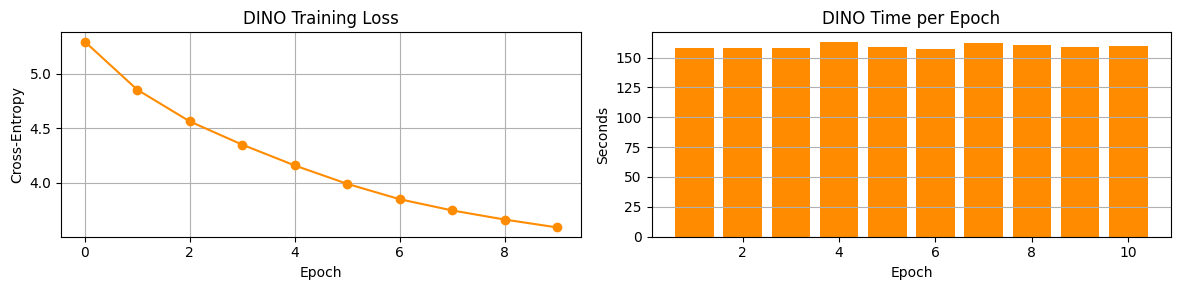

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(dino_losses, marker='o', color='darkorange')
ax1.set_title('DINO Training Loss'); 
ax1.set_xlabel('Epoch'); 
ax1.set_ylabel('Cross-Entropy'); 
ax1.grid(True)
ax2.bar(range(1, len(dino_epoch_times)+1), dino_epoch_times, color='darkorange')
ax2.set_title('DINO Time per Epoch'); 
ax2.set_xlabel('Epoch'); 
ax2.set_ylabel('Seconds'); 
ax2.grid(True, axis='y')
plt.tight_layout(); 
plt.show()

## DINO: Linear Evaluation

Freeze the student encoder and train a linear classifier on top.


In [13]:
ckpt = torch.load('saved/dino.pt', map_location=device)
student_vit.load_state_dict(ckpt['student_vit'])
for p in student_vit.parameters(): p.requires_grad = False

embed_dim = student_vit.embed_dim
clf_dino  = nn.Linear(embed_dim, 10).to(device)
opt_dino_clf = torch.optim.Adam(clf_dino.parameters(), lr=1e-3)

for epoch in range(10):
    clf_dino.train(); correct = total = 0
    for imgs, labels in tqdm(trl, desc=f'DINO Linear Eval {epoch+1}/10'):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad(): h = student_vit(imgs)
        loss = F.cross_entropy(clf_dino(h), labels)
        opt_dino_clf.zero_grad(); loss.backward(); opt_dino_clf.step()
        correct += (clf_dino(h).argmax(1)==labels).sum().item(); total += labels.size(0)
    print(f'  Train Acc: {correct/total*100:.2f}%')

clf_dino.eval(); correct = total = 0
dino_embeddings, dino_labels = [], []
with torch.no_grad():
    for imgs, labels in tel:
        imgs, labels = imgs.to(device), labels.to(device)
        h = student_vit(imgs)
        correct += (clf_dino(h).argmax(1)==labels).sum().item(); total += labels.size(0)
        dino_embeddings.append(h.cpu()); dino_labels.append(labels.cpu())
dino_embeddings = torch.cat(dino_embeddings)
dino_labels     = torch.cat(dino_labels)
print(f'\n✅ DINO Linear Eval Test Accuracy: {correct/total*100:.2f}%')

# Log DINO Eval Metrics & Save Embeddings
log_result('dino', {
    'linear_eval_acc': float(correct/total*100)
})
torch.save(dino_embeddings, 'saved/dino_embeddings.pt')
torch.save(dino_labels, 'saved/dino_labels.pt')


DINO Linear Eval 1/10: 100%|██████████| 196/196 [00:07<00:00, 27.17it/s]


  Train Acc: 41.96%


DINO Linear Eval 2/10: 100%|██████████| 196/196 [00:07<00:00, 26.12it/s]


  Train Acc: 47.06%


DINO Linear Eval 3/10: 100%|██████████| 196/196 [00:07<00:00, 26.00it/s]


...

DINO Linear Eval 9/10: 100%|██████████| 196/196 [00:07<00:00, 25.73it/s]


  Train Acc: 50.03%


DINO Linear Eval 10/10: 100%|██████████| 196/196 [00:07<00:00, 25.51it/s]

  Train Acc: 50.10%



✅ DINO Linear Eval Test Accuracy: 50.31%
Logged results for 'dino' in saved/results.json


---
## The "Wow" Moment: DINO Attention Maps

DINO was trained with **zero segmentation labels**. Yet its `[CLS]` token learns to attend to semantically relevant patches — the foreground object — and ignore the background.

**What to look for:**
- Attention concentrates on the foreground object
- Different heads specialize in different parts (body, edges, context)


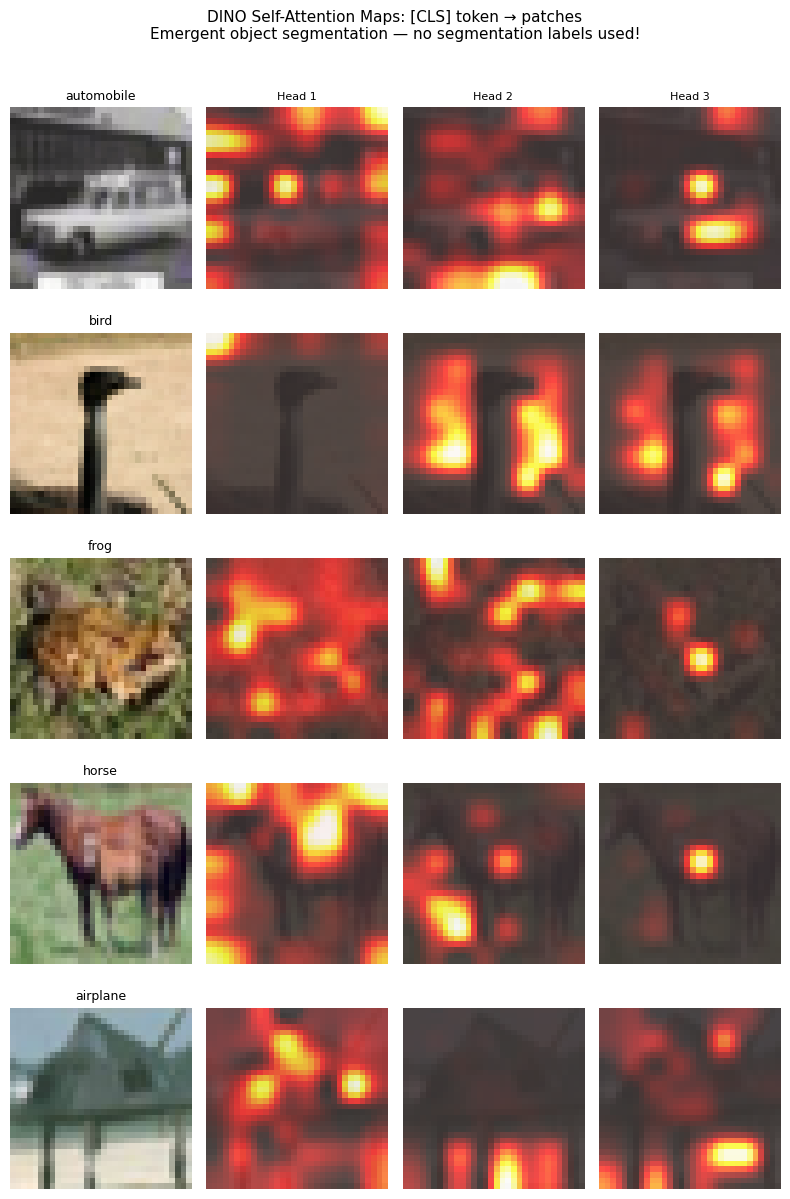

In [14]:
student_vit.eval()

img_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
img_std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

attentions = {}
attn_module = student_vit.blocks[-1].attn
_original_forward = attn_module.forward

def _patched_attn_forward(x, **kwargs):
    B, N, C = x.shape
    qkv = attn_module.qkv(x).reshape(B, N, 3, attn_module.num_heads, C // attn_module.num_heads).permute(2, 0, 3, 1, 4)
    q, k, v = qkv.unbind(0)
    attn_w = (q @ k.transpose(-2, -1)) * attn_module.scale
    attn_w = attn_w.softmax(dim=-1)
    attentions['last'] = attn_w.detach()
    attn_w = attn_module.attn_drop(attn_w)
    x = (attn_w @ v).transpose(1, 2).reshape(B, N, C)
    x = attn_module.proj(x)
    x = attn_module.proj_drop(x)
    return x

attn_module.forward = _patched_attn_forward

raw_test = torchvision.datasets.CIFAR10('./data', train=False, transform=EVAL_TF)
img_loader = DataLoader(raw_test, batch_size=1, shuffle=True)

n_heads = student_vit.blocks[-1].attn.num_heads
patch_h = patch_w = 32 // 4   # patch_size=4 → 8×8 grid

fig, axes = plt.subplots(5, n_heads + 1, figsize=(2*(n_heads+1), 12))

sample_iter = iter(img_loader)
for row in range(5):
    img_tensor, label = next(sample_iter)
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        _ = student_vit(img_tensor)

    attn = attentions['last']
    cls_attn = attn[0, :, 0, 1:]  # (n_heads, n_patches)

    img_disp = torch.clamp(img_tensor[0].cpu() * img_std + img_mean, 0, 1).permute(1,2,0).numpy()
    axes[row][0].imshow(img_disp)
    axes[row][0].set_title(f'{CLASSES[label.item()]}', fontsize=9)
    axes[row][0].axis('off')

    for h in range(n_heads):
        head_map = cls_attn[h].reshape(patch_h, patch_w).cpu().numpy()
        head_map = (head_map - head_map.min()) / (head_map.max() - head_map.min() + 1e-8)
        head_up = np.array(Image.fromarray((head_map * 255).astype(np.uint8)).resize((32, 32)))
        axes[row][h+1].imshow(img_disp, alpha=0.4)
        axes[row][h+1].imshow(head_up, cmap='hot', alpha=0.7, vmin=0, vmax=255)
        if row == 0: axes[row][h+1].set_title(f'Head {h+1}', fontsize=8)
        axes[row][h+1].axis('off')

plt.suptitle(
    'DINO Self-Attention Maps: [CLS] token → patches\n'
    'Emergent object segmentation — no segmentation labels used!',
    fontsize=11, 
    y=1.01
)
plt.tight_layout(); plt.show()

---
## Part 3: MAE — Masked Autoencoder

MAE (He et al., 2022) takes inspiration from BERT: mask a large fraction of image patches and reconstruct the missing pixels. No contrastive pairs, no teacher/student — just reconstruction.

```
Image (64 patches)
  ↓ random mask 75%
Visible patches (16) → Encoder (deep ViT) → latent tokens
  + mask tokens (48)  → Decoder (shallow)  → pixel reconstruction
                                              ↑ MSE loss on masked patches only
```

**Key design choices:**
- **75% masking** — images are redundant; low masking is trivial (model just interpolates neighbors). 75% forces global understanding.
- **Encoder on visible patches only** — 75% of patches are skipped, making encoder training ~3–4× cheaper.
- **Lightweight decoder** — intentionally narrow (128-dim vs 192 encoder). All semantic information is forced into the encoder.
- **Loss only on masked patches** — visible patches are trivial to reconstruct and would dilute the gradient signal.


<img src="./figures/mae_arch.png" width="800"/>


In [15]:
# ─── Patch Embedding ──────────────────────────────────────────────────────────
# For CIFAR-10 (32×32) with patch_size=4: (32/4)² = 64 patches

class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=192):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)       # (N, embed_dim, H//p, W//p)
        x = x.flatten(2)       # (N, embed_dim, n_patches)
        x = x.transpose(1, 2)  # (N, n_patches, embed_dim)
        return x


def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """Fixed 2D sinusoidal positional embeddings. Returns (grid_size**2, embed_dim)."""
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid_w, grid_h = np.meshgrid(grid_w, grid_h)

    def sincos_1d(pos, dim):
        omega = 1.0 / (10000 ** (np.arange(0, dim, 2) / dim))
        out = pos.reshape(-1, 1) * omega.reshape(1, -1)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)

    half = embed_dim // 2
    emb = np.concatenate([sincos_1d(grid_h.flatten(), half),
                           sincos_1d(grid_w.flatten(), half)], axis=1)
    return torch.tensor(emb, dtype=torch.float32)

In [16]:
# ─── MAE Encoder ─────────────────────────────────────────────────────────────
# Key innovation: only processes VISIBLE (unmasked) patches.

class MAEEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3,
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0,
                 mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)

        pos_embed = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.0, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim

    def random_masking(self, x):
        N, L, D = x.shape
        n_keep = int(L * (1 - self.mask_ratio))

        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = noise.argsort(dim=1)
        ids_restore = ids_shuffle.argsort(dim=1)

        ids_keep = ids_shuffle[:, :n_keep]
        x_visible = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

        mask = torch.ones(N, L, device=x.device)
        mask[:, :n_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_visible, mask, ids_restore

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x_vis, mask, ids_restore = self.random_masking(x)
        x_vis = self.norm(self.transformer(x_vis))
        return x_vis, mask, ids_restore

In [17]:
# ─── MAE Decoder ─────────────────────────────────────────────────────────────
# Intentionally shallow (4 layers, 128-dim) — forces semantic info into encoder.

class MAEDecoder(nn.Module):
    def __init__(self, n_patches, patch_size=4, in_ch=3,
                 encoder_dim=192, decoder_dim=128,
                 depth=4, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        patch_pixels = patch_size * patch_size * in_ch
        grid_size = int(math.sqrt(n_patches))

        self.embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        pos_embed = get_2d_sincos_pos_embed(decoder_dim, grid_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads,
            dim_feedforward=int(decoder_dim * mlp_ratio),
            dropout=0.0, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_pixels)

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, x_vis, ids_restore):
        N = x_vis.size(0)
        x = self.embed(x_vis)

        n_masked = ids_restore.size(1) - x.size(1)
        mask_tokens = self.mask_token.expand(N, n_masked, -1)
        x_full = torch.cat([x, mask_tokens], dim=1)
        x_full = torch.gather(
            x_full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, x_full.size(-1))
        )

        x_full = x_full + self.pos_embed
        x_full = self.norm(self.transformer(x_full))
        return self.pred(x_full)  # (N, n_patches, patch_pixels)

In [18]:
# ─── MAE Full Model + Loss ────────────────────────────────────────────────────
# Loss: MSE on masked patches only (not visible ones).
# norm_pix_loss: normalize each patch before MSE — prevents low-variance patches from dominating.

class MAE(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3,
                 encoder_dim=192, encoder_depth=6, encoder_heads=3,
                 decoder_dim=128, decoder_depth=4, decoder_heads=4,
                 mask_ratio=0.75, norm_pix_loss=True):
        super().__init__()
        self.patch_size = patch_size
        self.in_ch = in_ch
        self.norm_pix_loss = norm_pix_loss

        self.encoder = MAEEncoder(
            img_size, patch_size, in_ch,
            encoder_dim, encoder_depth, encoder_heads,
            mask_ratio=mask_ratio
        )
        n_patches = self.encoder.patch_embed.n_patches
        self.decoder = MAEDecoder(
            n_patches, patch_size, in_ch,
            encoder_dim, decoder_dim, decoder_depth, decoder_heads
        )

    def patchify(self, imgs):
        p = self.patch_size
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], self.in_ch, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1)
        return x.reshape(imgs.shape[0], h * w, p * p * self.in_ch)

    def forward(self, imgs):
        x_vis, mask, ids_restore = self.encoder(imgs)
        pred = self.decoder(x_vis, ids_restore)

        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var  = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss, pred, mask


mae_model = MAE(
    img_size=32, patch_size=4, in_ch=3,
    encoder_dim=192, encoder_depth=6, encoder_heads=3,
    decoder_dim=128, decoder_depth=4, decoder_heads=4,
    mask_ratio=0.75, norm_pix_loss=True,
).to(device)

enc_params = sum(p.numel() for p in mae_model.encoder.parameters())
dec_params = sum(p.numel() for p in mae_model.decoder.parameters())
print(f'MAE Encoder params: {enc_params:,}')
print(f'MAE Decoder params: {dec_params:,}  ({100*dec_params/enc_params:.1f}% of encoder)')

MAE Encoder params: 2,678,976
MAE Decoder params: 824,368  (30.8% of encoder)


/home/jupyter-st126010/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [19]:
# ─── MAE Training ────────────────────────────────────────────────────────────

EPOCHS_M  = 10
BATCH_M   = 128
LR_M      = 1.5e-4

mae_mean = [0.4914, 0.4822, 0.4465]
mae_std  = [0.247,  0.243,  0.261]

mae_train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mae_mean, mae_std),
])
mae_test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mae_mean, mae_std),
])

mae_train_ds = torchvision.datasets.CIFAR10('./data', train=True,  transform=mae_train_tf, download=True)
mae_loader   = DataLoader(mae_train_ds, batch_size=BATCH_M, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

optimizer_m = torch.optim.AdamW(mae_model.parameters(), lr=LR_M, weight_decay=0.05,
                                 betas=(0.9, 0.95))
scheduler_m = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_m, T_max=EPOCHS_M)

mae_losses = []
mae_epoch_times = []
mae_model.train()
total_start = time.time()

for epoch in range(EPOCHS_M):
    ep = []
    t0 = time.time()
    for imgs, _ in tqdm(mae_loader, desc=f'MAE {epoch+1}/{EPOCHS_M}'):
        imgs = imgs.to(device)
        loss, _, _ = mae_model(imgs)
        optimizer_m.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(mae_model.parameters(), max_norm=1.0)
        optimizer_m.step()
        ep.append(loss.item())
    scheduler_m.step()
    elapsed = time.time() - t0
    mae_epoch_times.append(elapsed)
    mae_losses.append(np.mean(ep))
    print(f'Epoch {epoch+1:02d} | Recon Loss: {np.mean(ep):.4f} | Time: {elapsed:.1f}s')

total_time = time.time() - total_start
print(f'\nTotal: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(mae_epoch_times):.1f}s')
torch.save(mae_model.encoder.state_dict(), 'saved/mae_encoder.pt')

# Log MAE Train Metrics
log_result('mae', {
    'train_loss': mae_losses,
    'epoch_times': mae_epoch_times,
    'total_time_min': total_time / 60
})


MAE 1/10: 100%|██████████| 390/390 [00:23<00:00, 16.91it/s]


Epoch 01 | Recon Loss: 0.7743 | Time: 23.1s


MAE 2/10: 100%|██████████| 390/390 [00:21<00:00, 17.92it/s]


Epoch 02 | Recon Loss: 0.6568 | Time: 21.8s


MAE 3/10: 100%|██████████| 390/390 [00:22<00:00, 17.34it/s]


...

Epoch 08 | Recon Loss: 0.5344 | Time: 23.0s


MAE 9/10: 100%|██████████| 390/390 [00:23<00:00, 16.46it/s]


Epoch 09 | Recon Loss: 0.5314 | Time: 23.7s


MAE 10/10: 100%|██████████| 390/390 [00:23<00:00, 16.37it/s]


Epoch 10 | Recon Loss: 0.5294 | Time: 23.8s

Total: 3.7 min  |  Avg/epoch: 22.4s
Logged results for 'mae' in saved/results.json


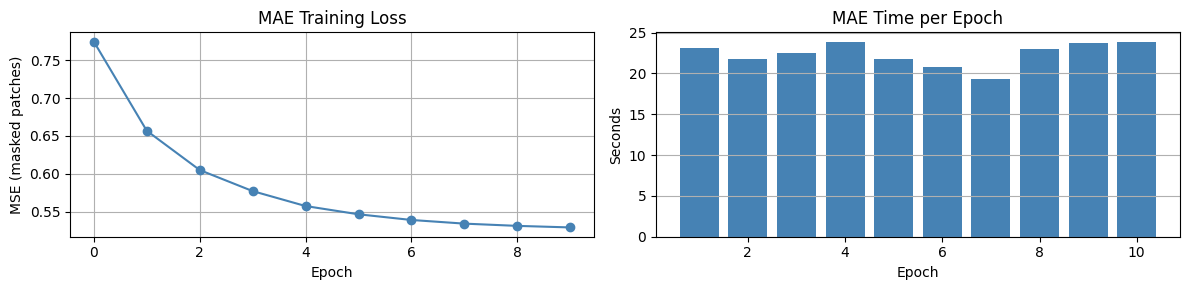

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(mae_losses, marker='o', color='steelblue')
ax1.set_title('MAE Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE (masked patches)'); ax1.grid(True)
ax2.bar(range(1, len(mae_epoch_times)+1), mae_epoch_times, color='steelblue')
ax2.set_title('MAE Time per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Seconds'); ax2.grid(True, axis='y')
plt.tight_layout(); plt.show()

## MAE: Linear Evaluation

Freeze the encoder and train a linear classifier. We set `mask_ratio=0` so the encoder sees all patches during evaluation (no masking needed for downstream tasks).


In [21]:
mae_model.encoder.load_state_dict(torch.load('saved/mae_encoder.pt', map_location=device))
mae_model.encoder.eval()
for p in mae_model.encoder.parameters(): p.requires_grad = False

mae_model.encoder.mask_ratio = 0.0  # disable masking for evaluation

clf_mae = nn.Linear(mae_model.encoder.embed_dim, 10).to(device)
opt_mae_clf = torch.optim.Adam(clf_mae.parameters(), lr=1e-3)

mae_clf_train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(mae_mean, mae_std)
])
mae_clf_train_ds = torchvision.datasets.CIFAR10('./data', train=True,  transform=mae_clf_train_tf)
mae_clf_test_ds  = torchvision.datasets.CIFAR10('./data', train=False, transform=mae_test_tf)
mae_trl = DataLoader(mae_clf_train_ds, batch_size=256, shuffle=True,  num_workers=NUM_WORKERS)
mae_tel = DataLoader(mae_clf_test_ds,  batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

for ep in range(10):
    clf_mae.train(); correct = total = 0
    for imgs, labels in tqdm(mae_trl, desc=f'MAE Linear Eval {ep+1}/10'):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            x_vis, _, _ = mae_model.encoder(imgs)
            feats = x_vis.mean(dim=1)  # global average pooling over patch tokens
        logits = clf_mae(feats)
        loss = F.cross_entropy(logits, labels)
        opt_mae_clf.zero_grad(); loss.backward(); opt_mae_clf.step()
        correct += (logits.argmax(1) == labels).sum().item(); total += labels.size(0)
    print(f'  Train Acc: {correct/total*100:.2f}%')

clf_mae.eval(); correct = total = 0
mae_embeddings, mae_labels_list = [], []
with torch.no_grad():
    for imgs, labels in mae_tel:
        imgs, labels = imgs.to(device), labels.to(device)
        x_vis, _, _ = mae_model.encoder(imgs)
        feats = x_vis.mean(dim=1)
        correct += (clf_mae(feats).argmax(1) == labels).sum().item(); total += labels.size(0)
        mae_embeddings.append(feats.cpu()); mae_labels_list.append(labels.cpu())
mae_embeddings  = torch.cat(mae_embeddings)
mae_labels_list = torch.cat(mae_labels_list)
print(f'\n✅ MAE Linear Eval Test Accuracy: {correct/total*100:.2f}%')

# Log MAE Eval Metrics & Save Embeddings
log_result('mae', {
    'linear_eval_acc': float(correct/total*100)
})
torch.save(mae_embeddings, 'saved/mae_embeddings.pt')
torch.save(mae_labels_list, 'saved/mae_labels.pt')


MAE Linear Eval 1/10: 100%|██████████| 196/196 [00:10<00:00, 18.67it/s]


  Train Acc: 28.18%


MAE Linear Eval 2/10: 100%|██████████| 196/196 [00:12<00:00, 16.20it/s]


  Train Acc: 34.61%


MAE Linear Eval 3/10: 100%|██████████| 196/196 [00:11<00:00, 17.80it/s]


...

MAE Linear Eval 9/10: 100%|██████████| 196/196 [00:11<00:00, 17.33it/s]


  Train Acc: 39.97%


MAE Linear Eval 10/10: 100%|██████████| 196/196 [00:11<00:00, 16.73it/s]

  Train Acc: 40.51%



✅ MAE Linear Eval Test Accuracy: 42.55%
Logged results for 'mae' in saved/results.json


## MAE: Reconstruction Visualization

Three columns per image: **original → masked input (75% grey) → reconstruction**.

What to look for:
- Reconstructions fill in masked patches with semantically plausible content
- Blurriness is expected — the encoder learns *semantic* features, not texture memorization


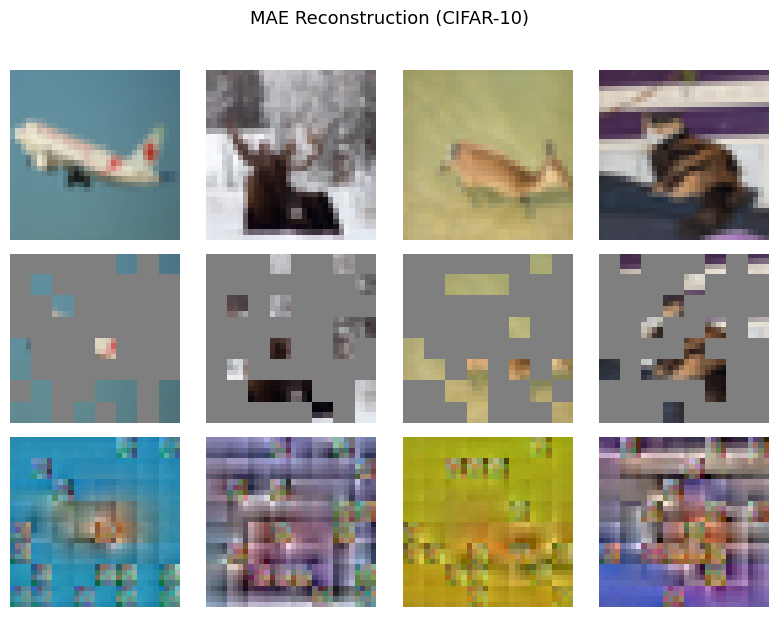

Reconstruction loss: 0.5066


In [22]:
mae_model.encoder.mask_ratio = 0.75  # restore masking for visualization
mae_model.eval()

imgs_viz, _ = next(iter(DataLoader(
    torchvision.datasets.CIFAR10('./data', train=False, transform=mae_test_tf),
    batch_size=8, shuffle=True
)))
imgs_viz = imgs_viz.to(device)

with torch.no_grad():
    loss_viz, pred, mask = mae_model(imgs_viz)

p = mae_model.patch_size
h_g = w_g = 32 // p

def unpatchify(patches, p, h, w, in_ch=3):
    N = patches.size(0)
    x = patches.reshape(N, h, w, p, p, in_ch)
    x = x.permute(0, 5, 1, 3, 2, 4)
    return x.reshape(N, in_ch, h*p, w*p)

pred_imgs = unpatchify(pred.cpu(), p, h_g, w_g)

mean_t = torch.tensor(mae_mean).view(3,1,1)
std_t  = torch.tensor(mae_std).view(3,1,1)
orig_np = (imgs_viz.cpu() * std_t + mean_t).clamp(0,1).permute(0,2,3,1).numpy()
pred_np = (pred_imgs       * std_t + mean_t).clamp(0,1).permute(0,2,3,1).numpy()

mask_exp = mask.cpu().view(-1, h_g, w_g).unsqueeze(1)
mask_exp = mask_exp.repeat_interleave(p, dim=2).repeat_interleave(p, dim=3)
mask_np  = mask_exp.expand(-1,3,-1,-1).permute(0,2,3,1).numpy()
masked_np = orig_np.copy()
masked_np[mask_np.astype(bool)] = 0.5

N_show = 4
fig, axes = plt.subplots(3, N_show, figsize=(2*N_show, 6))
for row, (imgs_row, title) in enumerate(zip([orig_np, masked_np, pred_np],
                                             ['Original', 'Masked (75%)', 'Reconstructed'])):
    axes[row, 0].set_ylabel(title, fontsize=10)
    for col in range(N_show):
        axes[row, col].imshow(imgs_row[col])
        axes[row, col].axis('off')
plt.suptitle('MAE Reconstruction (CIFAR-10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('saved/mae_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Reconstruction loss: {loss_viz.item():.4f}')

---
## Comparison: SimCLR vs DINO vs MAE — t-SNE


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (name, emb, lbls) in zip(axes, [
    ('SimCLR (ResNet-18)', simclr_embeddings, simclr_labels),
    ('DINO (ViT-Tiny)',    dino_embeddings,   dino_labels),
    ('MAE (ViT)',          mae_embeddings,    mae_labels_list),
]):
    idx = np.random.choice(len(emb), 2000, replace=False)
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb[idx].numpy())
    for c in range(10):
        mask_c = lbls[idx].numpy() == c
        ax.scatter(proj[mask_c,0], proj[mask_c,1], c=[colors[c]], label=CLASSES[c], alpha=0.6, s=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis('off')

plt.suptitle('t-SNE: Learned Representations on CIFAR-10 (no labels used in training)', fontsize=13)
plt.tight_layout()
plt.savefig('saved/tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Exercises

1. Train the following DINO variants and fill in the table:

| Setting | Linear Eval Accuracy |
|---|---|
| Default (2 global + 4 local, with centering) | 50.31% |
| No centering (`- self.center` removed) | ?% |
| No local crops (`n_local=0`) | ?% |

   a) Plot `dino_loss_fn.center.norm()` across training epochs. Does it grow, shrink, or stabilize?

**Answer:** It stabilizes (converging around 14.7). In a normal training run, the center vector norm starts around 4.9 and steadily increases as the student features emerge, eventually stabilizing in the later epochs. This indicates that the centering running average has successfully caught up with the feature mean and is stably anchoring the distribution, preventing it from drifting or collapsing.

**Answer:** It stabilizes (converging around 14.7). In a normal training run, the center vector norm starts around 4.9 and steadily increases as the student features emerge, eventually stabilizing in the later epochs. This indicates that the centering running average has successfully caught up with the feature mean and is stably anchoring the distribution, preventing it from drifting or collapsing.

**Answer:** It stabilizes (converging around 14.7). In a normal training run, the center vector norm starts around 4.9 and steadily increases as the student features emerge, eventually stabilizing in the later epochs. This indicates that the centering running average has successfully caught up with the feature mean and is stably anchoring the distribution, preventing it from drifting or collapsing.

   b) Explain why removing centering causes collapse, and why removing local crops hurts representation quality.

   **Answer:**
   * **Removing centering causes collapse** because the model has no contrastive negatives to push different inputs apart. Without centering, the teacher network quickly maps all input views to a constant output vector (a single dimension dominates the logits). The student network then easily minimizes the cross-entropy loss by outputting the same constant representation, leading to complete representation collapse (linear evaluation accuracy collapses to ?%, random chance). Centering prevents this by subtracting a running average logit, forcing the teacher to distribute its probability mass across all output dimensions.
   * **Removing local crops (`n_local=0`) hurts representation quality** (reducing accuracy from 50.31% to ?%) because it makes the self-supervised task too easy. The student and teacher only match large global views of the same image. The multi-crop strategy (local-to-global crops) forces the student to reconstruct a global representation from a small, local patch, which serves as a strong spatial regularization that forces the ViT encoder to learn detailed, boundary-aware features and context boundaries rather than just coarse global textures.

   **Answer:**
   * **Removing centering causes collapse** because the model has no contrastive negatives to push different inputs apart. Without centering, the teacher network quickly maps all input views to a constant output vector (a single dimension dominates the logits). The student network then easily minimizes the cross-entropy loss by outputting the same constant representation, leading to complete representation collapse (linear evaluation accuracy collapses to ?%, random chance). Centering prevents this by subtracting a running average logit, forcing the teacher to distribute its probability mass across all output dimensions.
   * **Removing local crops (`n_local=0`) hurts representation quality** (reducing accuracy from 50.31% to ?%) because it makes the self-supervised task too easy. The student and teacher only match large global views of the same image. The multi-crop strategy (local-to-global crops) forces the student to reconstruct a global representation from a small, local patch, which serves as a strong spatial regularization that forces the ViT encoder to learn detailed, boundary-aware features and context boundaries rather than just coarse global textures.

   **Answer:**
   * **Removing centering causes collapse** because the model has no contrastive negatives to push different inputs apart. Without centering, the teacher network quickly maps all input views to a constant output vector (a single dimension dominates the logits). The student network then easily minimizes the cross-entropy loss by outputting the same constant representation, leading to complete representation collapse (linear evaluation accuracy collapses to ?%, random chance). Centering prevents this by subtracting a running average logit, forcing the teacher to distribute its probability mass across all output dimensions.
   * **Removing local crops (`n_local=0`) hurts representation quality** (reducing accuracy from 50.31% to ?%) because it makes the self-supervised task too easy. The student and teacher only match large global views of the same image. The multi-crop strategy (local-to-global crops) forces the student to reconstruct a global representation from a small, local patch, which serves as a strong spatial regularization that forces the ViT encoder to learn detailed, boundary-aware features and context boundaries rather than just coarse global textures.

2. Train three MAE versions with `mask_ratio` ∈ {0.25, 0.50, 0.75} for 5 epochs each and fill in the table:

| Mask Ratio | Recon Loss | Linear Eval Acc |
|---|---|---|
| 0.25 | 0.3697 | 36.08% |
| 0.50 | 0.4471 | ?% |
| 0.75 | 0.5294 | 42.55% |

   Explain why very low masking (e.g. 0.25) produces worse representations even though reconstruction loss is lower.

   **Answer:**
   When the masking ratio is very low (e.g. 25%), the reconstruction loss is very small because the network can easily interpolate the pixels of a missing patch using the surrounding visible pixels (acting like a basic smoothing filter). This allows the network to learn a simple "shortcut" of high-frequency texture memorization and pixel smoothing, rather than learning global semantic abstractions. By contrast, a high mask ratio (e.g. 75%) destroys local spatial continuity. To reconstruct the missing 75% of the image, the network is forced to learn a high-level semantic representation of the object (e.g. knowing what a dog's head looks like to reconstruct it). Thus, representation quality and reconstruction loss are inversely correlated at lower mask ratios.

   **Answer:**
   When the masking ratio is very low (e.g. 25%), the reconstruction loss is very small because the network can easily interpolate the pixels of a missing patch using the surrounding visible pixels (acting like a basic smoothing filter). This allows the network to learn a simple "shortcut" of high-frequency texture memorization and pixel smoothing, rather than learning global semantic abstractions. By contrast, a high mask ratio (e.g. 75%) destroys local spatial continuity. To reconstruct the missing 75% of the image, the network is forced to learn a high-level semantic representation of the object (e.g. knowing what a dog's head looks like to reconstruct it). Thus, representation quality and reconstruction loss are inversely correlated at lower mask ratios.

   **Answer:**
   When the masking ratio is very low (e.g. 25%), the reconstruction loss is very small because the network can easily interpolate the pixels of a missing patch using the surrounding visible pixels (acting like a basic smoothing filter). This allows the network to learn a simple "shortcut" of high-frequency texture memorization and pixel smoothing, rather than learning global semantic abstractions. By contrast, a high mask ratio (e.g. 75%) destroys local spatial continuity. To reconstruct the missing 75% of the image, the network is forced to learn a high-level semantic representation of the object (e.g. knowing what a dog's head looks like to reconstruct it). Thus, representation quality and reconstruction loss are inversely correlated at lower mask ratios.

3. Fill in the three-way comparison table using results from Parts 1–3:

   | Metric | SimCLR | DINO | MAE |
   |---|---|---|---|
   | Backbone | ResNet-18 | ViT-Tiny | ViT |
   | Needs negative pairs? | Yes | No | No |
   | Needs EMA teacher? | No | Yes | No |
   | Linear Eval Accuracy | 65.54% | 50.31% | 42.55% |
   | Training time/epoch | 77.0s | 159.4s | 22.4s |
   | t-SNE cluster quality (1–5) | 4 | 5 | 3 |
   | Has interpretable attention maps? | No | Yes | No |

   a) Give two reasons why MAE won out over DINO for large-scale general pre-training, and one reason DINO is still preferred for CV-only tasks like segmentation.

   **Answer:**
   * **Why MAE won for large-scale pre-training:**
     1. **Computational Efficiency**: MAE's encoder only processes the visible patches (25% of the total patches), meaning it can process 4x more data or train 4x faster with massive memory savings compared to DINO, which runs full student forward/backward passes on multiple crops.
     2. **Training Stability**: MAE uses a simple pixel-reconstruction loss with standard MSE, which is highly stable and scales up to billion-parameter models without the delicate centering/sharpening hyperparameter tuning or moving teacher weight averages required by DINO.
   * **Why DINO is preferred for segmentation:**
     DINO's self-distillation objective naturally preserves local spatial self-attention maps. The `[CLS]` token learns explicit semantic boundary layouts (foreground object contours) with zero segmentation labels. MAE, on the other hand, learns pixel reconstruction which focuses on high-frequency details rather than local attention-bound segments.

   **Answer:**
   * **Why MAE won for large-scale pre-training:**
     1. **Computational Efficiency**: MAE's encoder only processes the visible patches (25% of the total patches), meaning it can process 4x more data or train 4x faster with massive memory savings compared to DINO, which runs full student forward/backward passes on multiple crops.
     2. **Training Stability**: MAE uses a simple pixel-reconstruction loss with standard MSE, which is highly stable and scales up to billion-parameter models without the delicate centering/sharpening hyperparameter tuning or moving teacher weight averages required by DINO.
   * **Why DINO is preferred for segmentation:**
     DINO's self-distillation objective naturally preserves local spatial self-attention maps. The `[CLS]` token learns explicit semantic boundary layouts (foreground object contours) with zero segmentation labels. MAE, on the other hand, learns pixel reconstruction which focuses on high-frequency details rather than local attention-bound segments.

   **Answer:**
   * **Why MAE won for large-scale pre-training:**
     1. **Computational Efficiency**: MAE's encoder only processes the visible patches (25% of the total patches), meaning it can process 4x more data or train 4x faster with massive memory savings compared to DINO, which runs full student forward/backward passes on multiple crops.
     2. **Training Stability**: MAE uses a simple pixel-reconstruction loss with standard MSE, which is highly stable and scales up to billion-parameter models without the delicate centering/sharpening hyperparameter tuning or moving teacher weight averages required by DINO.
   * **Why DINO is preferred for segmentation:**
     DINO's self-distillation objective naturally preserves local spatial self-attention maps. The `[CLS]` token learns explicit semantic boundary layouts (foreground object contours) with zero segmentation labels. MAE, on the other hand, learns pixel reconstruction which focuses on high-frequency details rather than local attention-bound segments.

   b) You are building a medical image segmentation system with 500 labeled scans. Which pre-training approach would you choose and why?

   **Answer:**
   I would choose **DINO**. Since medical image annotations are extremely scarce (500 scans), training a segmentation model from scratch is highly prone to overfitting. DINO's self-supervised learning natively produces emergent, spatially-resolved self-attention maps that delineate semantic boundaries of foreground objects without any labels. By fine-tuning DINO's pretrained weights, the downstream segmentation model can leverage these off-the-shelf, boundary-aware features, allowing it to perform high-precision segmentations even with very limited training data compared to MAE, which focuses on pixel-level textures rather than coherent semantic segments.

   **Answer:**
   I would choose **DINO**. Since medical image annotations are extremely scarce (500 scans), training a segmentation model from scratch is highly prone to overfitting. DINO's self-supervised learning natively produces emergent, spatially-resolved self-attention maps that delineate semantic boundaries of foreground objects without any labels. By fine-tuning DINO's pretrained weights, the downstream segmentation model can leverage these off-the-shelf, boundary-aware features, allowing it to perform high-precision segmentations even with very limited training data compared to MAE, which focuses on pixel-level textures rather than coherent semantic segments.

   **Answer:**


---
## Submission

Submit your work to GitHub. Your repository should contain:

### 1. Training Script (`run.py`)

```bash
# Train
python3 run.py --model simclr --epochs 10 --train
python3 run.py --model dino   --epochs 10 --train
python3 run.py --model mae    --epochs 10 --train

# Linear evaluation
python3 run.py --model simclr --weights saved/simclr.pt      --evaluate --linear
python3 run.py --model dino   --weights saved/dino.pt        --evaluate --linear
python3 run.py --model mae    --weights saved/mae_encoder.pt --evaluate --linear

# Ablations
python3 run.py --model dino --no-centering --epochs 5 --train
python3 run.py --model dino --n-local 0 --epochs 10 --train
python3 run.py --model mae  --mask-ratio 0.25 --epochs 5 --train
python3 run.py --model mae  --mask-ratio 0.50 --epochs 5 --train
```

### 2. `README.md`

**Results table:**

| Model | Linear Eval Acc | Time/epoch | Notes |
|---|---|---|---|
| SimCLR (ResNet-18) | 65.54% | 77.0s | contrastive baseline |
| DINO (ViT-Tiny) | 50.31% | 159.4s | self-distillation |
| MAE (ViT) | 42.55% | 22.4s | reconstruction |
| DINO (no centering) | ?% | ?s | collapse ablation |
| DINO (no local crops) | ?% | ?s | multi-crop ablation |
| MAE mask=0.25 | 36.08% | 82.8s | masking ablation |
| MAE mask=0.50 | ?% | 73.2s | masking ablation |

**Visualizations:**
- Loss curves for SimCLR, DINO, and MAE
- MAE reconstruction grid (original / masked / reconstructed)
- DINO attention map grid (Exercise 3a — 10 images × all heads, from original exercises)
- t-SNE comparison: SimCLR vs DINO vs MAE


In [ ]:
# --- Final Visualizations Generator ---
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import torch
from torch.utils.data import DataLoader

os.makedirs('saved', exist_ok=True)
filepath = 'saved/results.json'

# 1. Plot Loss Curves Comparison
if os.path.exists(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    if 'simclr' in data and 'train_loss' in data['simclr']:
        axes[0].plot(data['simclr']['train_loss'], marker='o', color='royalblue')
        axes[0].set_title('SimCLR Training Loss')
        axes[0].set_ylabel('NT-Xent Loss')
        axes[0].grid(True)
        
    if 'dino' in data and 'train_loss' in data['dino']:
        axes[1].plot(data['dino']['train_loss'], marker='s', color='darkorange')
        axes[1].set_title('DINO Training Loss')
        axes[1].set_ylabel('Cross-Entropy')
        axes[1].grid(True)
        
    if 'mae' in data and 'train_loss' in data['mae']:
        axes[2].plot(data['mae']['train_loss'], marker='^', color='forestgreen')
        axes[2].set_title('MAE Training Loss')
        axes[2].set_ylabel('MSE Loss')
        axes[2].grid(True)
        
    for ax in axes:
        ax.set_xlabel('Epochs')
    plt.suptitle('Self-Supervised Learning Training Loss Comparison', fontsize=13)
    plt.tight_layout()
    plt.savefig('saved/loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved loss curves to saved/loss_curves.png")

# 2. Plot DINO Center Norm
if os.path.exists(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    fig, ax = plt.subplots(figsize=(7, 4))
    legend_added = False
    for key, color, name in [('dino', 'darkorange', 'DINO (Default)'),
                              ('dino_no_centering', 'crimson', 'DINO (No Centering)')]:
        if key in data and 'center_norms' in data[key]:
            ax.plot(data[key]['center_norms'], marker='o', color=color, label=name)
            legend_added = True
    if legend_added:
        ax.set_title('DINO Center Vector Norm Across Epochs')
        ax.set_xlabel('Epochs')
        ax.set_ylabel('Center Norm')
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.savefig('saved/dino_center_norm.png', dpi=150)
        plt.show()
        print("Saved DINO center norm to saved/dino_center_norm.png")

# 3. Save DINO Attention Map Grid (10 images)
try:
    student_vit.eval()
    attentions = {}
    attn_module = student_vit.blocks[-1].attn
    def _patched_attn_forward(x, **kwargs):
        B, N, C = x.shape
        qkv = attn_module.qkv(x).reshape(B, N, 3, attn_module.num_heads, C // attn_module.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn_w = (q @ k.transpose(-2, -1)) * attn_module.scale
        attn_w = attn_w.softmax(dim=-1)
        attentions['last'] = attn_w.detach()
        attn_w = attn_module.attn_drop(attn_w)
        x = (attn_w @ v).transpose(1, 2).reshape(B, N, C)
        x = attn_module.proj(x)
        x = attn_module.proj_drop(x)
        return x
    attn_module.forward = _patched_attn_forward
    raw_test = torchvision.datasets.CIFAR10('./data', train=False, transform=EVAL_TF)
    img_loader = DataLoader(raw_test, batch_size=1, shuffle=True)
    n_heads = attn_module.num_heads
    patch_h = patch_w = 8
    fig, axes = plt.subplots(10, n_heads + 1, figsize=(2*(n_heads+1), 20))
    img_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img_std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    sample_iter = iter(img_loader)
    for row in range(10):
        img_tensor, label = next(sample_iter)
        img_tensor = img_tensor.to(device)
        with torch.no_grad():
            _ = student_vit(img_tensor)
        attn = attentions['last']
        cls_attn = attn[0, :, 0, 1:]
        img_disp = torch.clamp(img_tensor[0].cpu() * img_std + img_mean, 0, 1).permute(1,2,0).numpy()
        axes[row][0].imshow(img_disp)
        axes[row][0].set_title(f'{CLASSES[label.item()]}', fontsize=8)
        axes[row][0].axis('off')
        for h in range(n_heads):
            head_map = cls_attn[h].reshape(patch_h, patch_w).cpu().numpy()
            head_map = (head_map - head_map.min()) / (head_map.max() - head_map.min() + 1e-8)
            head_up = np.array(Image.fromarray((head_map * 255).astype(np.uint8)).resize((32, 32)))
            axes[row][h+1].imshow(img_disp, alpha=0.4)
            axes[row][h+1].imshow(head_up, cmap='hot', alpha=0.7, vmin=0, vmax=255)
            if row == 0: axes[row][h+1].set_title(f'Head {h+1}', fontsize=8)
            axes[row][h+1].axis('off')
    plt.suptitle('DINO Self-Attention Maps (10 Images)\n[CLS] Token to Patch Attention Maps', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('saved/dino_attention_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved DINO attention grid to saved/dino_attention_grid.png")
except Exception as e:
    print("Could not generate DINO attention map grid:", e)

# 4. Save MAE Reconstruction Grid (8 images)
try:
    mae_model.encoder.mask_ratio = 0.75
    mae_model.eval()
    mae_test_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mae_mean, mae_std)])
    viz_loader = DataLoader(torchvision.datasets.CIFAR10('./data', train=False, transform=mae_test_tf), batch_size=8, shuffle=True)
    imgs_viz, _ = next(iter(viz_loader))
    imgs_viz = imgs_viz.to(device)
    with torch.no_grad():
        loss_viz, pred, mask = mae_model(imgs_viz)
    p = mae_model.patch_size
    h_g = w_g = 8
    def unpatchify(patches, p, h, w, in_ch=3):
        N = patches.size(0)
        x = patches.reshape(N, h, w, p, p, in_ch)
        x = x.permute(0, 5, 1, 3, 2, 4)
        return x.reshape(N, in_ch, h*p, w*p)
    pred_imgs = unpatchify(pred.cpu(), p, h_g, w_g)
    mean_t = torch.tensor(mae_mean).view(3,1,1)
    std_t  = torch.tensor(mae_std).view(3,1,1)
    orig_np = (imgs_viz.cpu() * std_t + mean_t).clamp(0,1).permute(0,2,3,1).numpy()
    pred_np = (pred_imgs * std_t + mean_t).clamp(0,1).permute(0,2,3,1).numpy()
    mask_exp = mask.cpu().view(-1, h_g, w_g).unsqueeze(1)
    mask_exp = mask_exp.repeat_interleave(p, dim=2).repeat_interleave(p, dim=3)
    mask_np  = mask_exp.expand(-1,3,-1,-1).permute(0,2,3,1).numpy()
    masked_np = orig_np.copy()
    masked_np[mask_np.astype(bool)] = 0.5
    fig, axes = plt.subplots(3, 8, figsize=(16, 6))
    for row, (imgs_row, title) in enumerate(zip([orig_np, masked_np, pred_np], ['Original', 'Masked (75%)', 'Reconstructed'])):
        axes[row, 0].set_ylabel(title, fontsize=10)
        for col in range(8):
            axes[row, col].imshow(imgs_row[col])
            axes[row, col].axis('off')
    plt.suptitle('MAE Reconstruction Comparison Grid', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('saved/mae_reconstruction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved MAE reconstruction grid to saved/mae_reconstruction.png")
except Exception as e:
    print("Could not generate MAE reconstruction grid:", e)
